   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  HousePrice  
0    -122.23       4.526  
1    -122.22       3.585  
2    -122.24       3.521  
3    -122.25       3.413  
4    -122.25       3.422  
(20640, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population 

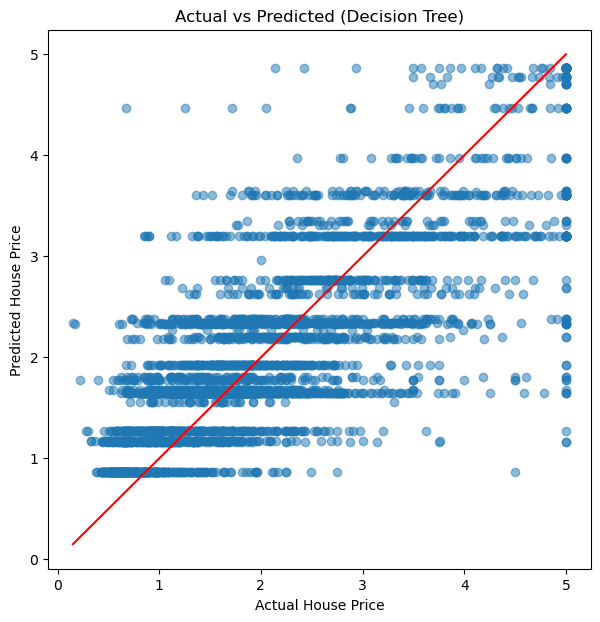

      Feature  Importance
0      MedInc    0.771212
5    AveOccup    0.128407
1    HouseAge    0.041621
2    AveRooms    0.031261
6    Latitude    0.022049
4  Population    0.002485
7   Longitude    0.002097
3   AveBedrms    0.000869


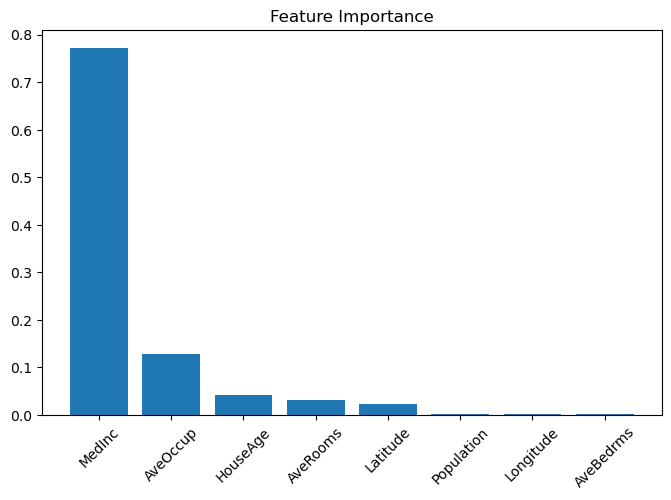

Project Completed
Best Performing Model: Decision Tree
                       RMSE  R2 Score
Linear Regression  0.745581  0.575788
Ridge Regression   0.745557  0.575816
Decision Tree      0.724234  0.599732


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

data = fetch_california_housing(as_frame=True)

df = pd.concat(
    [data.data, data.target.rename("HousePrice")],
    axis=1
)

print(df.head())
print(df.shape)
print(df.info())
print(df.isnull().sum())
print(df.describe())

X = df.drop("HousePrice", axis=1)
y = df["HousePrice"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(max_depth=5, random_state=42)
}

results = {}
predictions_dict = {}

for name, model in models.items():

    if name == "Decision Tree":
        model.fit(X_train, y_train)
        predictions = model.predict(X_test)
    else:
        model.fit(X_train_scaled, y_train)
        predictions = model.predict(X_test_scaled)

    predictions_dict[name] = predictions

    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    results[name] = {
        "RMSE": rmse,
        "R2 Score": r2
    }

results_df = pd.DataFrame(results).T

print(results_df)

best_model_name = results_df["R2 Score"].idxmax()

print("Best Model:", best_model_name)

best_predictions = predictions_dict[best_model_name]

plt.figure(figsize=(7,7))
plt.scatter(y_test, best_predictions, alpha=0.5)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)
plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title(f"Actual vs Predicted ({best_model_name})")
plt.show()

tree = models["Decision Tree"]

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": tree.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

plt.figure(figsize=(8,5))
plt.bar(
    importance["Feature"],
    importance["Importance"]
)
plt.xticks(rotation=45)
plt.title("Feature Importance")
plt.show()

print("Project Completed")
print("Best Performing Model:", best_model_name)
print(results_df)